# Training Results — LoRA Fine-tuning on SVG Generation

Eval loss curves for both training runs on `Qwen2.5-3B-Instruct`.


In [50]:
%pip install matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [51]:
import pandas as pd


## v1: `qwen3b_svg_lora` — rank=8, alpha=16, ~1 epoch (~3063 steps)
Eval every 500 steps

| Run | Inference Params | Leaderboard Score |
|-----|-----------------|-------------------|
| **Run 1** | `do_sample=False`, no repetition penalty (greedy) | **15.03** (best) |
| **Run 2** | `do_sample=True`, `temperature=0.2`, `top_p=0.9`, `repetition_penalty=1.3` | **14.40** (worse) |

Run 2 was worse despite sampling being a common best practice for text generation. The `repetition_penalty=1.3` is the culprit — SVG path `d=` attributes repeat coordinate values by design (e.g. `M 10 20 L 30 20`), and the penalty suppresses tokens that have already appeared, actively corrupting geometrically valid sequences.


In [52]:
v1 = pd.DataFrame({
    'Step':      [500,    1000,   1500,   2000,   2500,   3000],
    'Eval Loss': [0.4076, 0.3759, 0.3608, 0.3522, 0.3469, 0.3449],
})
v1.style.format({'Eval Loss': '{:.4f}'}).set_table_styles([
    {'selector': 'table, th, td', 'props': [('background-color', 'white'), ('color', 'black'), ('border', '1px solid #ccc')]}

])

,Step,Eval Loss
0,500,0.4076
1,1000,0.3759
2,1500,0.3608
3,2000,0.3522
4,2500,0.3469
5,3000,0.3449


## v2: `qwen3b_svg_lora_v2` — rank=16, alpha=32, ~2 epochs (~5090 steps)
**Leaderboard score: 14.81** | Eval every 250 steps

> Note: The small uptick at step 3500 (0.2934 → 0.2944) is caused by the LR scheduler restarting its warmup cycle at the epoch boundary (~step 1300 and ~step 3300).


In [53]:
v2 = pd.DataFrame({
    'Step': [
        250,    500,    750,    1000,   1250,   1500,   1750,   2000,   2250,   2500,
        2750,   3000,   3250,   3500,   3750,   4000,   4250,   4500,   4750,   5000
    ],
    'Training Loss': [
        0.4347, 0.3568, 0.3751, 0.3293, 0.3266, 0.3188, 0.3118, 0.3158, 0.3152, 0.3044,
        0.2988, 0.2922, 0.2871, 0.2978, 0.2947, 0.2919, 0.2975, 0.2906, 0.2801, 0.2849
    ],
    'Eval Loss': [
        0.4056, 0.3564, 0.3390, 0.3303, 0.3216, 0.3185, 0.3132, 0.3081, 0.3054, 0.3006,
        0.2978, 0.2959, 0.2934, 0.2944, 0.2941, 0.2922, 0.2896, 0.2880, 0.2863, 0.2841
    ],
})
v2.style.format({'Training Loss': '{:.4f}', 'Eval Loss': '{:.4f}'}).set_table_styles([
    {'selector': 'table, th, td', 'props': [('background-color', 'white'), ('color', 'black'), ('border', '1px solid #ccc')]}

])

,Step,Training Loss,Eval Loss
0,250,0.4347,0.4056
1,500,0.3568,0.3564
2,750,0.3751,0.3390
3,1000,0.3293,0.3303
4,1250,0.3266,0.3216
5,1500,0.3188,0.3185
6,1750,0.3118,0.3132
7,2000,0.3158,0.3081
8,2250,0.3152,0.3054
9,2500,0.3044,0.3006


## Comparison Summary

| Run | Model | LoRA Rank | Alpha | max_seq_len | Epochs | Steps | Final Eval Loss | `do_sample` | `rep_penalty` | Leaderboard Score |
|-----|-------|-----------|-------|-------------|--------|-------|-----------------|-------------|---------------|-------------------|
| v1 Run 1 | Qwen2.5-3B | 8 | 16 | 1024 | ~1 | 3063 | 0.3449 | `False` | none | **15.03** (best) |
| v1 Run 2 | Qwen2.5-3B | 8 | 16 | 1024 | ~1 | 3063 | 0.3449 | `True` | 1.3 | 14.40 |
| v2 Run 3 | Qwen2.5-3B | 16 | 32 | 1536 | ~2 | 5090 | 0.2841 | `False` | 1.05 | 14.81 |

**Key observations:**
- v1 Run 1 vs Run 2 are the **same trained model** — the only difference is inference params. The drop from 15.03 → 14.40 is entirely caused by `repetition_penalty=1.3` corrupting SVG path coordinates.
- v2 achieved a **much lower eval loss** (0.2841 vs 0.3449) but scored **worse on the leaderboard** (14.81 vs 15.03). Lower cross-entropy loss does not guarantee better visual similarity — possible overfitting, or the confounded changes (rank, seq_len, epochs, system prompt) introducing regressions.
- The best leaderboard result came from the simplest decoding strategy: greedy with no penalty.


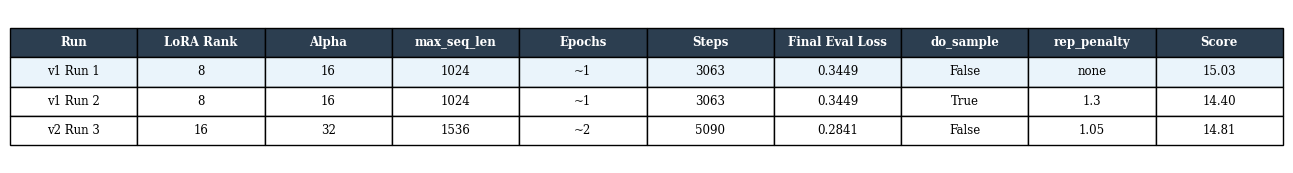

In [54]:

import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({'font.family': 'serif', 'font.size': 9})

columns = ['Run', 'LoRA Rank', 'Alpha', 'max_seq_len', 'Epochs', 'Steps',
           'Final Eval Loss', 'do_sample', 'rep_penalty', 'Score']
rows = [
    ['v1 Run 1', '8', '16', '1024', '~1', '3063', '0.3449', 'False', 'none',  '15.03'],
    ['v1 Run 2', '8', '16', '1024', '~1', '3063', '0.3449', 'True',  '1.3',   '14.40'],
    ['v2 Run 3', '16', '32', '1536', '~2', '5090', '0.2841', 'False', '1.05', '14.81'],
]

fig, ax = plt.subplots(figsize=(13, 1.8))
ax.axis('off')

tbl = ax.table(cellText=rows, colLabels=columns, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.6)

# Style header
for j in range(len(columns)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Highlight best score row (v1 Run 1)
for j in range(len(columns)):
    tbl[1, j].set_facecolor('#eaf4fb')

# All other cells white
for i in range(2, len(rows) + 1):
    for j in range(len(columns)):
        if tbl[i, j].get_facecolor() == (1.0, 1.0, 1.0, 1.0):
            tbl[i, j].set_facecolor('white')

fig.tight_layout()
plt.show()


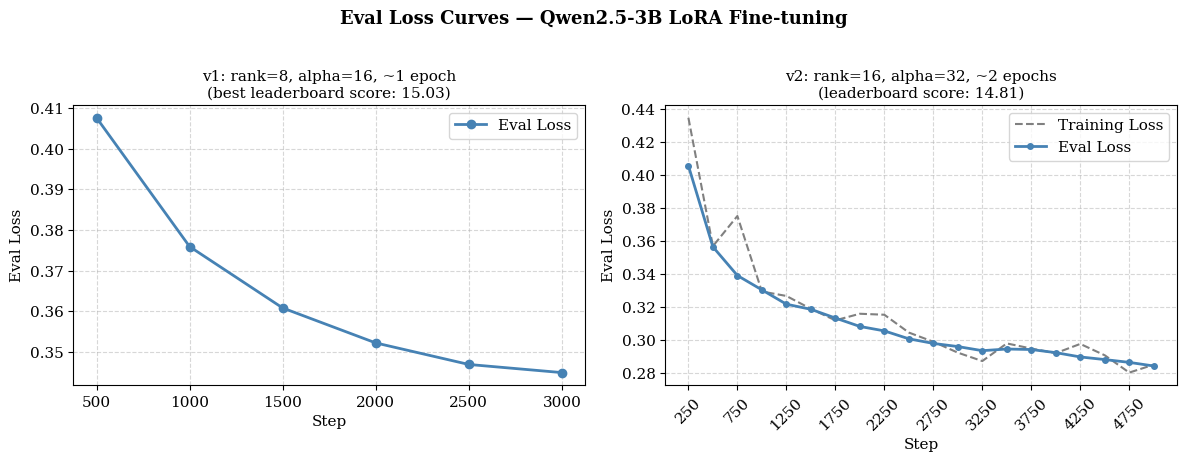

In [55]:

import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'font.family': 'serif',
    'font.size': 11,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# v1 
ax1 = axes[0]
ax1.plot(v1['Step'], v1['Eval Loss'], marker='o', linewidth=2, color='steelblue', label='Eval Loss')
ax1.set_title('v1: rank=8, alpha=16, ~1 epoch\n(best leaderboard score: 15.03)', fontsize=11)
ax1.set_xlabel('Step')
ax1.set_ylabel('Eval Loss')
ax1.set_xticks(v1['Step'])
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# v2 
ax2 = axes[1]
ax2.plot(v2['Step'], v2['Training Loss'], linewidth=1.5, color='gray', linestyle='--', label='Training Loss')
ax2.plot(v2['Step'], v2['Eval Loss'], marker='o', markersize=4, linewidth=2, color='steelblue', label='Eval Loss')
ax2.set_title('v2: rank=16, alpha=32, ~2 epochs\n(leaderboard score: 14.81)', fontsize=11)
ax2.set_xlabel('Step')
ax2.set_ylabel('Eval Loss')
ax2.set_xticks(v2['Step'][::2])
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

fig.suptitle('Eval Loss Curves — Qwen2.5-3B LoRA Fine-tuning', fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()
